<a href="https://colab.research.google.com/github/omkulawade03/Countries-Dataset/blob/main/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance (2).csv


In [32]:
filepath = "/content/insurance.csv"
df = pd.read_csv("insurance.csv")

In [33]:
#Q1. Load the insurance dataset using pandas.
#display the first 10 rows of the data.

df = pd.read_csv("insurance.csv")

print(df.head(10))



   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86
5   31  female  25.7         0     no  southeast   3756.62
6   46  female  33.4         1     no  southeast   8240.59
7   37  female  27.7         3     no  northwest   7281.51
8   37    male  29.8         2     no  northeast   6406.41
9   60  female  25.8         0     no  northwest  28923.14


In [34]:
#Q2. Use pandas functions to get basic information about the dataset:
#1 Shape of the data (shape)
#2 Column names and data types (info())
#3 Statistical summary of numerical columns (describe())

print("Shape:", df.shape)

print("\nInformation:")
df.info()

print("\nStatistical Summary:")
print(df.describe())


Shape: (1338, 7)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Statistical Summary:
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.00

In [35]:
#Q3. Check if the dataset contains any null/missing values.
#Show the count of null values for each column.

print(df.isnull().sum())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [36]:
#Q4. Identify numerical and categorical columns in the dataset.
#Print them separately.


numerical = df.select_dtypes(include=['int64', 'float64']).columns
categorical = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical)

print("\nCategorical Columns:")
print(categorical)


Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


--- Q5: Generating Distribution Plots... ---


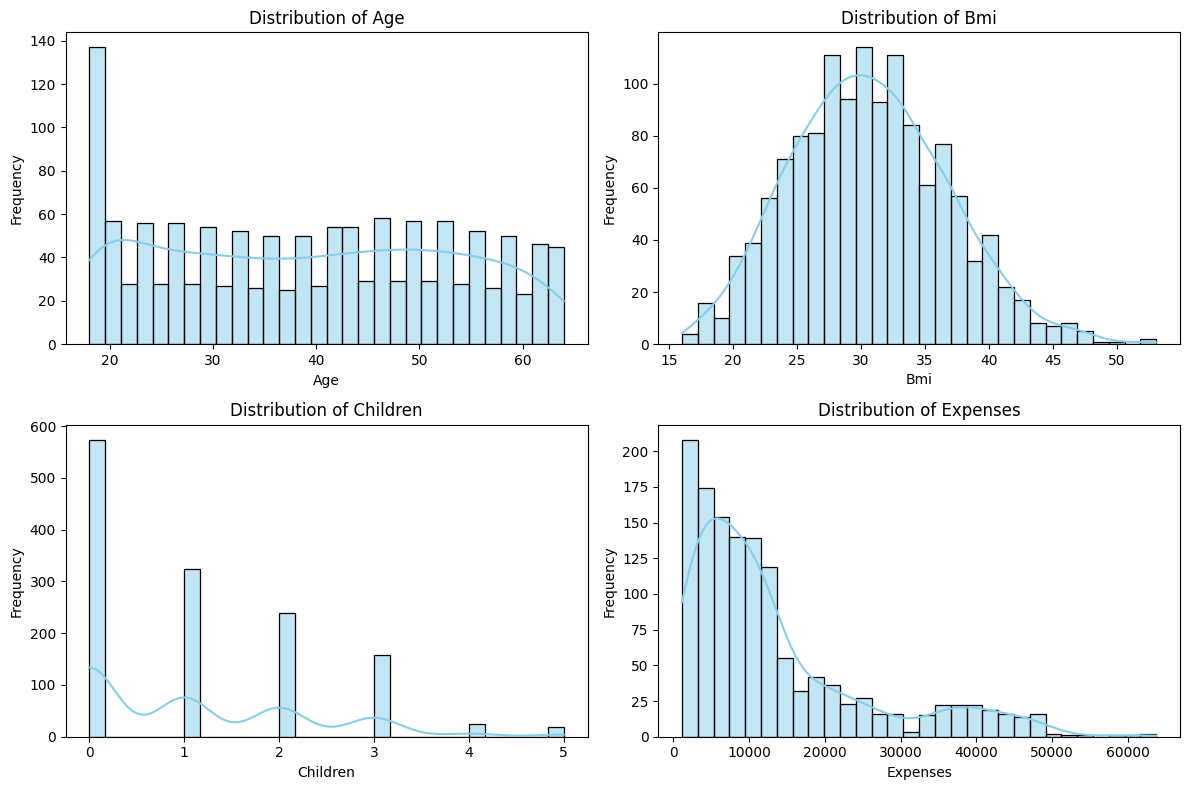

In [37]:
# --- Q5. Distribution plots for numerical columns ---
print("--- Q5: Generating Distribution Plots... ---")
# We create a 2x2 grid to fit all 4 numerical plots beautifully
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
plt.tight_layout() # This keeps the graphs from overlapping
plt.show()

--- Q6: Generating Count Plots... ---


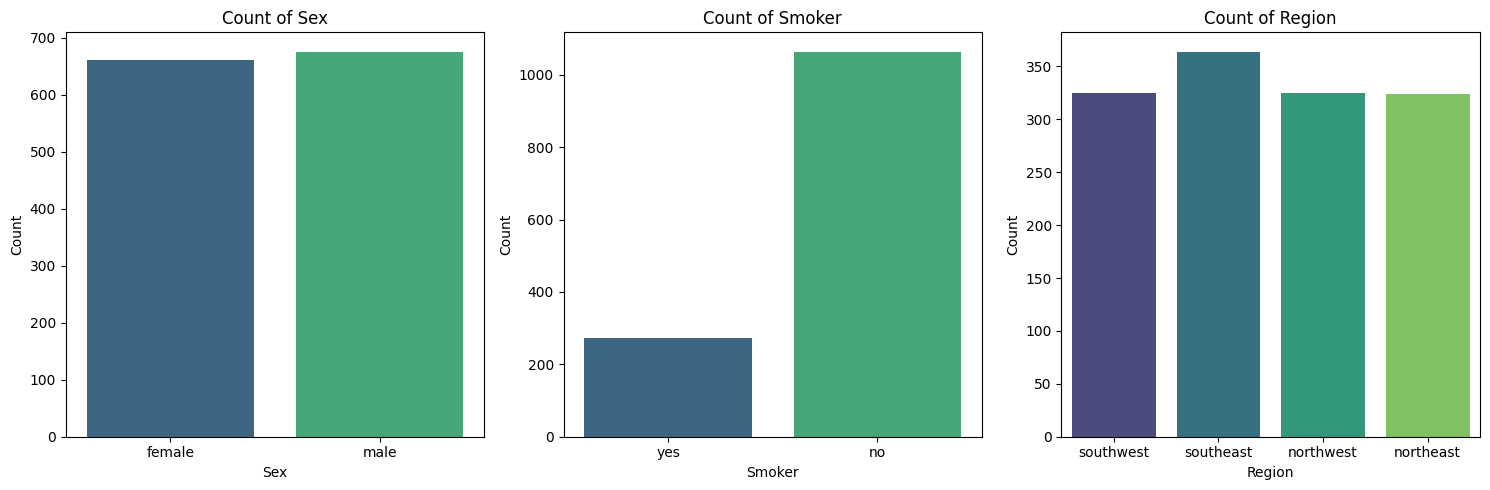

In [38]:
# --- Q6. Count plots for categorical columns ---
print("--- Q6: Generating Count Plots... ---")
# We create a 1x3 grid for the 3 categorical columns
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)

    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)

    plt.title(f'Count of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

--- Q7: Generating Correlation Heatmap... ---


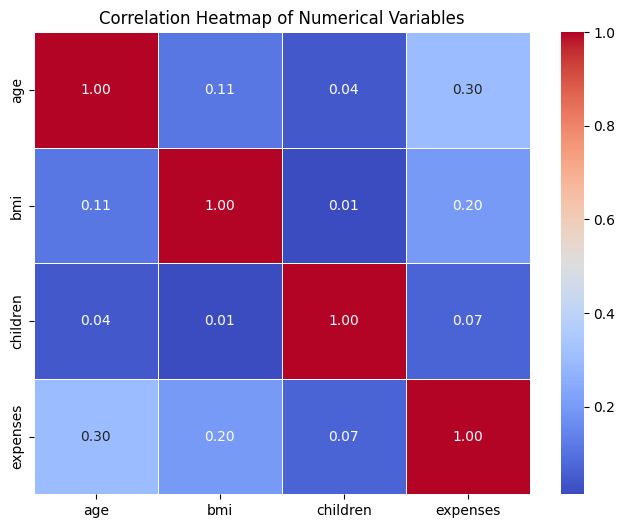

In [39]:
# --- Q7. Heatmap to show correlation ---
print("--- Q7: Generating Correlation Heatmap... ---")
plt.figure(figsize=(8, 6))

corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [40]:
# --- Q8. Analysis on the expenses column ---
print("--- Q8: Expenses Analysis ---")
# Using standard pandas math functions
avg_expense = df['expenses'].mean()
max_expense = df['expenses'].max()
min_expense = df['expenses'].min()

print(f"Average Insurance Expense: ${avg_expense:.2f}")
print(f"Maximum Insurance Expense: ${max_expense:.2f}")
print(f"Minimum Insurance Expense: ${min_expense:.2f}")

print("\nAverage expenses: Smokers vs Non-smokers:")
# Grouping by the 'smoker' column to compare the means
smoker_comp = df.groupby('smoker')['expenses'].mean()
print(smoker_comp)
print("\n")


--- Q8: Expenses Analysis ---
Average Insurance Expense: $13270.42
Maximum Insurance Expense: $63770.43
Minimum Insurance Expense: $1121.87

Average expenses: Smokers vs Non-smokers:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64




--- Q9: Generating Boxplot... ---


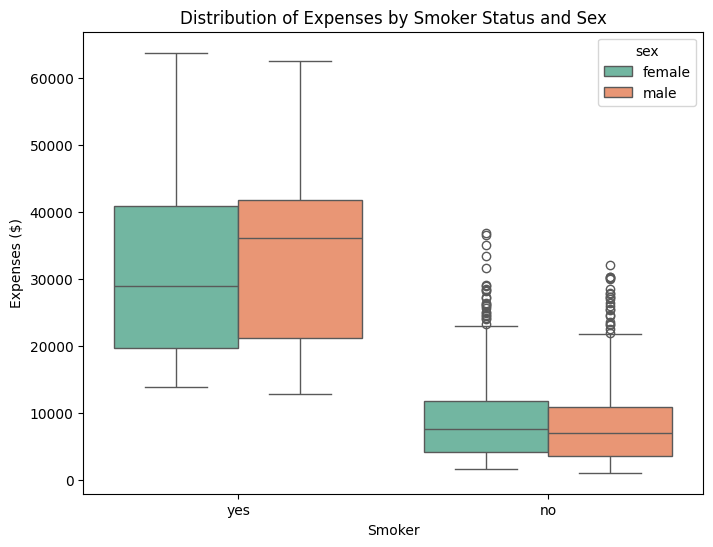

In [41]:
# --- Q9. Boxplot for charges with respect to smoker and sex ---
print("--- Q9: Generating Boxplot... ---")
plt.figure(figsize=(8, 6))
# The 'hue' parameter allows us to split the data further by sex
sns.boxplot(data=df, x='smoker', y='expenses', hue='sex', palette='Set2')
plt.title('Distribution of Expenses by Smoker Status and Sex')
plt.xlabel('Smoker')
plt.ylabel('Expenses ($)')
plt.show()

In [42]:
# --- Q10. Mini Project / Analysis Summary ---
print("=============================================")
print("     Q10: MINI PROJECT / ANALYSIS SUMMARY    ")
print("=============================================\n")

print("1. DEMOGRAPHICS:")
print("- Average Age: ~39.2 years")
print("- Average BMI: ~30.6\n")

print("2. SMOKING IMPACT:")
print("- Smoking is the biggest driver of high insurance costs.")
print("- Smokers pay roughly 3x to 4x more than non-smokers on average.\n")

print("3. REGIONS:")
print("- The Southeast region has the highest number of customers.\n")

print("4. KEY INSIGHTS:")
print("- Age Trend: Insurance charges increase steadily in a linear fashion as age increases.")
print("- BMI Threshold: High BMI only results in massive insurance cost spikes if the customer is ALSO a smoker.")
print("=============================================")

     Q10: MINI PROJECT / ANALYSIS SUMMARY    

1. DEMOGRAPHICS:
- Average Age: ~39.2 years
- Average BMI: ~30.6

2. SMOKING IMPACT:
- Smoking is the biggest driver of high insurance costs.
- Smokers pay roughly 3x to 4x more than non-smokers on average.

3. REGIONS:
- The Southeast region has the highest number of customers.

4. KEY INSIGHTS:
- Age Trend: Insurance charges increase steadily in a linear fashion as age increases.
- BMI Threshold: High BMI only results in massive insurance cost spikes if the customer is ALSO a smoker.
